[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Extra/X2-ValidationInTime.ipynb)

# X2 — Validation When Time and Trials Are Against You

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Extra material — optional: not covered in the lectures, and not examinable**

**When to read it:** after `X1`, and any time after Class 4. It uses cross-validation, leakage and `TimeSeriesSplit` (`02C` §6), and the tree ensembles of Class 4.

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`X1` assumed what the whole course has assumed since `02C`: that the rows can be shuffled, so that a
random split is a fair rehearsal of data the model has not seen. Two things break that assumption,
and both of them are the normal condition in finance, in any measurement that drifts, and in any
project where more than one idea was tried.

**The rows are ordered.** A model that will predict next month must be validated on data that came
after its training set, and features built from overlapping windows make neighbouring rows
near-duplicates of each other.

**Many things were tried before one was reported.** `X1` §3 showed the winner's curse over
features. The same arithmetic applies over models, over hyperparameters, over choices of universe
and horizon — over every decision made while looking at a score.

Neither is exotic and neither is only a finance problem: a drifting spectrometer, a detector
recalibrated halfway through a run, and a screen of two hundred candidate materials have the same
structure. But finance is where both appear at full strength at once, so the examples below are
written in its language. **This notebook is about method, not about investing, and nothing in it is
advice.**

## Learning Objectives

By the end of this notebook, students should be able to:

- explain why a random split is invalid on ordered data, and demonstrate it on data with no signal;
- state the one case where k-fold cross-validation *is* defensible on a time series;
- use **walk-forward** validation, and apply **purging** and an **embargo** when labels are built
  from overlapping windows;
- explain why the best of many trials is biased, and report the number of trials alongside the
  result;
- recognise **non-stationarity** and say what refitting does and does not fix;
- list what an honest report of a time-ordered result contains.

## Where this sits in the pipeline

Step 2 of the map — the split — is the box this notebook is about, and step 10's *monitoring and
retraining*, which the course names but never teaches, is where section 6 ends up.

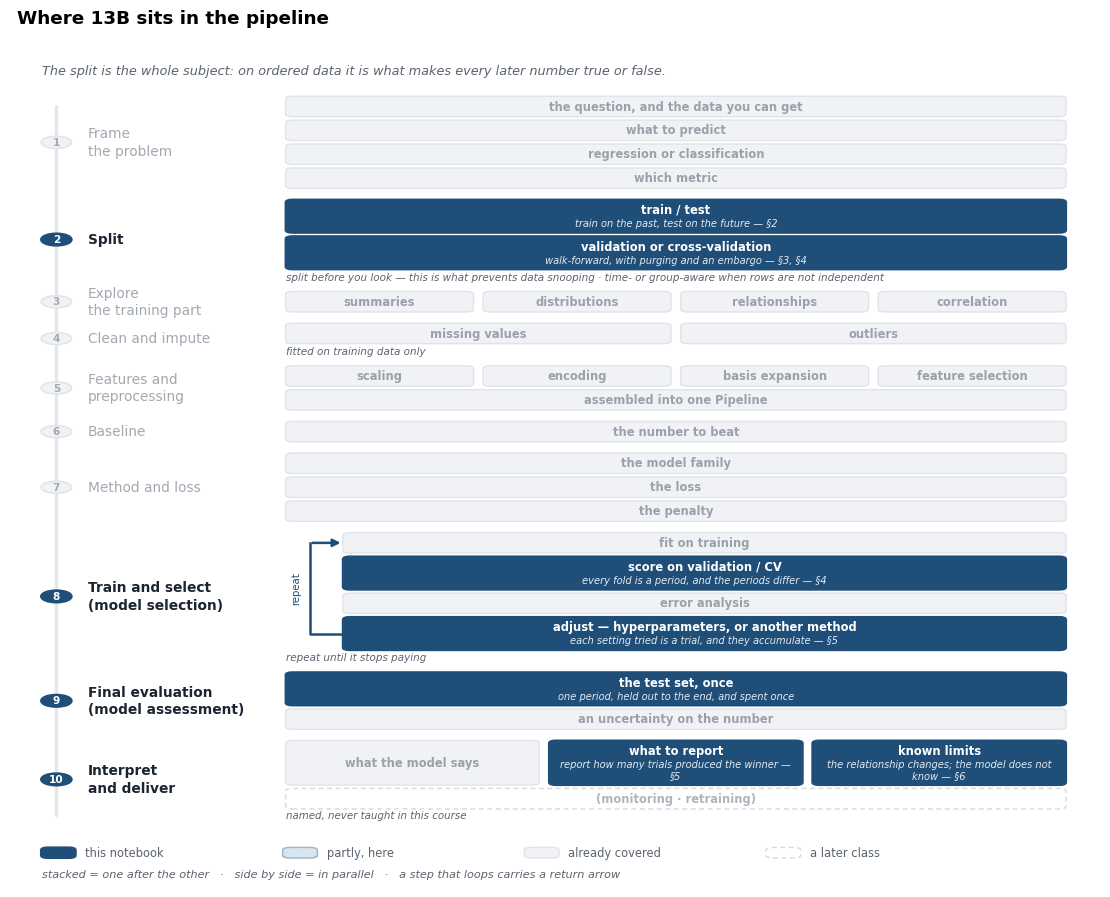

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2.1": "now", "2.2": "now", "3": "done", "4": "done", "5": "done",
     "5.after": "done", "6": "done", "7": "done",
     "8.1": "done", "8.2": "now", "8.3": "done", "8.4": "now",
     "9.1": "now", "9.2": "done", "10.1": "done", "10.2": "now", "10.3": "now"},
    notes={"2.1": "train on the past, test on the future — §2",
           "2.2": "walk-forward, with purging and an embargo — §3, §4",
           "8.2": "every fold is a period, and the periods differ — §4",
           "8.4": "each setting tried is a trial, and they accumulate — §5",
           "9.1": "one period, held out to the end, and spent once",
           "10.2": "report how many trials produced the winner — §5",
           "10.3": "the relationship changes; the model does not know — §6"},
    title="Where 13B sits in the pipeline",
    lead="The split is the whole subject: on ordered data it is what makes every later number true or false.")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit
from sklearn.metrics import r2_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

rng = np.random.default_rng(0)

# 1. A series with nothing in it

Everything below is measured on data built so that **there is no relationship to find**: a sequence
of independent normal draws, standing for daily returns. Any performance a procedure reports on it
is an artefact of the procedure.

**Independent normal draws are not what returns look like**, and the difference runs in the
uncomfortable direction. Real series have heavy tails and volatility clustering, and both make the
quantities below *harder* to estimate rather than easier: the sampling error of a Sharpe ratio
depends on the serial correlation and the non-normality of the returns it is computed from, so the
error bars in a real backtest are wider than the ones an independent-normal simulation would suggest
(Lo, *Financial Analysts Journal* 58, 2002). The artefacts demonstrated here are therefore a floor,
not a worst case.

The features are the ones anybody would build from such a series — a 20-day mean, a 60-day mean, a
20-day volatility — and the target is the sum of the next 20 days. That target is the reason this
notebook exists: **it overlaps**. The label at day $t$ and the label at day $t+1$ share nineteen of
their twenty terms.

In [ ]:
days, horizon = 2000, 20
returns = rng.normal(0, 1, days + 2 * horizon)          # no signal, by construction


def features_at(t):
    """What an analyst would have on the morning of day t, and nothing from after it."""
    return [returns[t - horizon:t].mean(),               # 20-day mean
            returns[max(0, t - 60):t].mean(),            # 60-day mean
            returns[t - horizon:t].std()]                # 20-day volatility


X = np.array([features_at(t) for t in range(horizon, days + horizon)])
y = np.array([returns[t:t + horizon].sum() for t in range(horizon, days + horizon)])

print(f"{len(y)} days, {X.shape[1]} features, and no relationship between them")
print(f"correlation between the labels of consecutive days: "
      f"{np.corrcoef(y[:-1], y[1:])[0, 1]:.3f}")
print(f"distance between consecutive rows of features, against a typical pair: "
      f"{np.linalg.norm(X[1:] - X[:-1], axis=1).mean():.3f} against "
      f"{np.linalg.norm(X[rng.permutation(len(X))] - X, axis=1).mean():.3f}")

2000 days, 3 features, and no relationship between them
correlation between the labels of consecutive days: 0.949
distance between consecutive rows of features, against a typical pair: 0.074 against 0.390


Two numbers say everything about what follows. Consecutive labels correlate at **0.95**, because
they are sums over almost the same twenty days. Consecutive rows of features sit **five times closer
together** than two rows picked at random, because they are averages over almost the same window.

Rows like that are near-duplicates. A random split puts one of a pair in the training set and the
other in the test set, and a model flexible enough to find its neighbour can then hand back the
neighbour's label as its prediction. With consecutive labels correlating at 0.95, that guess
accounts for about **90% of the variance** of the label it is predicting — on data containing
nothing at all.

# 2. What a random split reports

The cell scores the same model two ways: `KFold(shuffle=True)`, the default of the whole course so
far, and `TimeSeriesSplit`, which trains on a prefix and tests on what follows (`02C` §6.4).

In [ ]:
forest = lambda: RandomForestRegressor(200, min_samples_leaf=2, n_jobs=-1, random_state=0)

random_split = cross_val_score(forest(), X, y, cv=KFold(5, shuffle=True, random_state=0),
                               scoring="r2")
forward = cross_val_score(forest(), X, y, cv=TimeSeriesSplit(5), scoring="r2")

print(f"random 5-fold cross-validation : R2 {random_split.mean():+.3f}")
print(f"forward validation in time     : R2 {forward.mean():+.3f}")
print(f"\nthe truth, by construction     : R2  0.000")

random 5-fold cross-validation : R2 +0.204
forward validation in time     : R2 -0.600

the truth, by construction     : R2  0.000


**The random split reports that 20% of the variance is explained.** There is nothing there. The
forward split reports a negative $R^2$, which is the correct answer for a model that has found
nothing and is adding noise.

Notice what the leak is *not*. No test row was used in training, no scaler saw the test set, nothing
in `X1` §4's sense happened. The leak is that the test rows have **near-duplicates** in the
training set, and near-duplicates carry the answer. That is why `02C` §6.4 insists the grouping is
something you know about the experiment: the same failure appears with three visits from one
patient, ten spectra from one sample, or several images from one specimen.

The figure below is the arrangement the rest of the notebook works with.

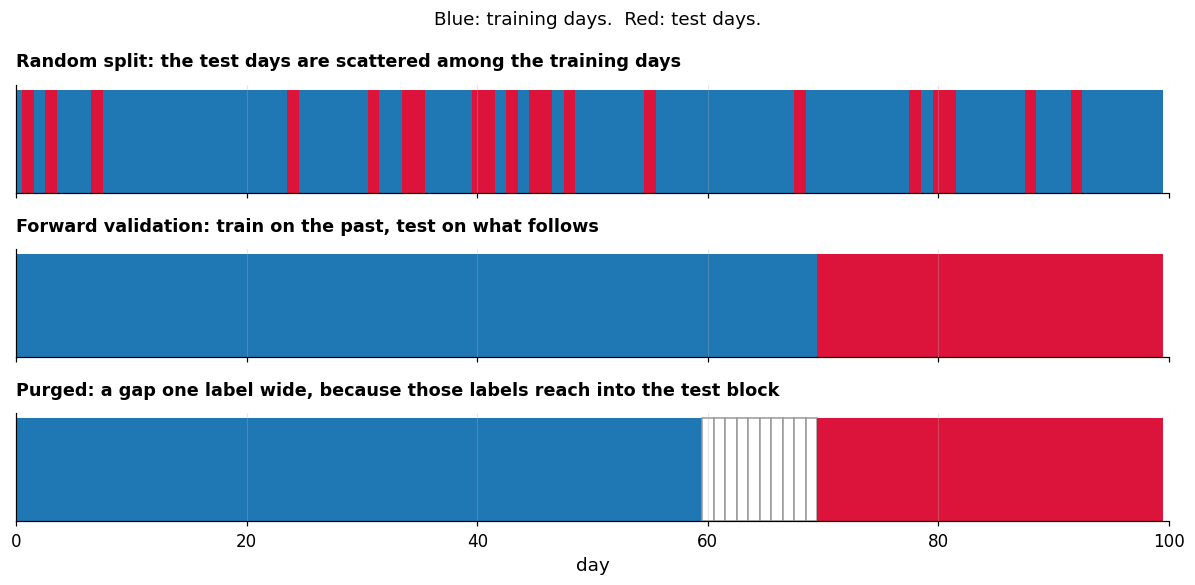

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 5.4), sharex=True)
timeline = np.arange(100)

for axis, title in zip(axes, ["Random split: the test days are scattered among the training days",
                              "Forward validation: train on the past, test on what follows",
                              "Purged: a gap one label wide, because those labels reach into the test block"]):
    axis.set_yticks([])
    axis.set_xlim(0, 100)
    axis.set_title(title, fontsize=11.5, loc="left")

scattered = rng.permutation(100)[:20]
axes[0].bar(timeline, 1, width=1.0, color=["crimson" if t in scattered else "tab:blue"
                                           for t in timeline])
axes[1].bar(timeline, 1, width=1.0, color=["crimson" if t >= 70 else "tab:blue" for t in timeline])
axes[2].bar(timeline, 1, width=1.0,
            color=["crimson" if t >= 70 else ("white" if t >= 60 else "tab:blue") for t in timeline],
            edgecolor=["none" if t < 60 or t >= 70 else "0.6" for t in timeline])
axes[2].set_xlabel("day")
fig.suptitle("Blue: training days.  Red: test days.", fontsize=12)
plt.show()

## 2.1 The honest exception

"Never use k-fold on a time series" is the usual advice, and it is too strong. Bergmeir and Benítez
(*Information Sciences* 191, 2012) and Bergmeir, Hyndman and Koo (*CSDA* 120, 2018) show that for a
**purely autoregressive** model, fitted to a stationary series, with errors that are uncorrelated
once the model is right, ordinary k-fold cross-validation is valid and uses the data better than a
single holdout.

The conditions are what matter. The demonstration above broke all three: the labels overlap, so the
errors are correlated by construction. In practice, that is the common case — any target defined
over a forward window, any feature smoothed over a trailing one. So the rule to carry is not "time
forbids k-fold" but:

> **A random split assumes that a training row tells you nothing about a test row.** Overlapping
> windows, repeated measurements of one subject, and slow drift all violate it, and each of them
> makes a random split report a number that cannot be achieved.

# 3. Purging and the embargo

Forward validation fixes the scattering, but not the boundary. Consider the last training day,
$t_{\text{end}}$. Its label was built from the twenty days that follow it — days that are **inside
the test period**. The model has therefore been told, through that one label, what happened at the
start of the block it is about to be scored on.

The remedies have names, from López de Prado's *Advances in Financial Machine Learning* (2018), ch.
7, which is where this problem is treated properly:

- **Purging** — drop the training rows whose label windows reach into the test period. Here that is
  the last twenty rows.
- **Embargo** — drop a further few rows *after* the test block before training resumes, because
  features built from trailing windows carry test-period information back into later training rows.

The leak lives at the boundary, so the cell measures the boundary: the correlation between
prediction and truth over the first twenty test days of each fold, with and without purging.

In [ ]:
def boundary_correlation(purge, rows=20, splits=5):
    """Correlation between prediction and truth over the first `rows` days of each test block."""
    predicted, actual = [], []
    for train, test in TimeSeriesSplit(splits).split(X):
        kept = train[:-purge] if purge else train
        model = forest().fit(X[kept], y[kept])
        predicted.append(model.predict(X[test[:rows]]))
        actual.append(y[test[:rows]])
    return np.corrcoef(np.concatenate(predicted), np.concatenate(actual))[0, 1]


print(f"{'':44}{'no purging':>13}{'20 days purged':>17}")
for rows, label in [(20, "first 20 test days (the label's own window)"),
                    (100, "first 100 test days")]:
    print(f"{label:44}{boundary_correlation(0, rows):>+13.3f}{boundary_correlation(20, rows):>+17.3f}")

                                               no purging   20 days purged


first 20 test days (the label's own window)        +0.282           +0.133


first 100 test days                                +0.024           -0.030


On data with nothing in it, the unpurged model's predictions correlate with the truth at **+0.282**
over the twenty days immediately after the boundary. Purging those twenty training rows halves it,
to +0.133. Over a hundred test days the effect is already gone — +0.024 against −0.030 — because
the leak is confined to one label's width.

That is the shape of the problem worth remembering: **the boundary leak is local, and it is
dangerous exactly when the test block is short.** A walk-forward with weekly refits and a twenty-day
label is almost entirely boundary. One long holdout is barely affected.

> The width of the purge is the width of the label, and you know it because you built the label. The
> embargo is different: nothing determines it, since it depends on how far back the features reach
> and how quickly the series forgets. López de Prado suggests a small fraction of the sample and
> treats the choice as one to state rather than to derive.

# 4. Walk-forward, and what to report from it

`TimeSeriesSplit` grows the training set and steps the test block forward. Two variants are in
common use, and they answer different questions.

**Expanding window** — train on everything up to the boundary. Suited to a stable relationship,
because more data is better.

**Rolling window** — train on the last $N$ days only. Suited to a drifting one, because old data
describe a world that no longer exists. Section 6 is about telling the two cases apart.

The choice is a studied question rather than a maxim, and the studies complicate it: with a
structural break, the window that minimises forecast error is generally **not** the post-break
window, because throwing away the older data costs more in estimation error than it saves in bias,
and averaging forecasts across several window lengths does better than trying to find the break
(Pesaran & Timmermann, 2007). "Use a rolling window when things drift" is the right instinct and the
wrong precision.

What comes out of a walk-forward is **a score per period, and they are not interchangeable**. A mean
across periods hides the thing you most need to see: whether the result came from all of them or
from one. `04B` §12's rule — report the spread, not only the mean — becomes sharper here, because
the folds are not exchangeable samples but named stretches of history, and a reader is entitled to
ask which ones worked.

# 5. The number of trials

`X1` §3 showed the winner's curse over features. Nothing in that argument was about features. It
applies to every choice made while watching a score: which model, which horizon, which universe,
which threshold, which of five preprocessing variants.

The cell below runs the experiment in its starkest form. Two hundred meaningless rules are applied
to the same noise series — each one takes the sign of its own random signal — and scored by the
**Sharpe ratio**, the annualised mean return divided by its standard deviation, which is finance's
name for a signal-to-noise ratio. The best is chosen on the first half and then tested on the
second.

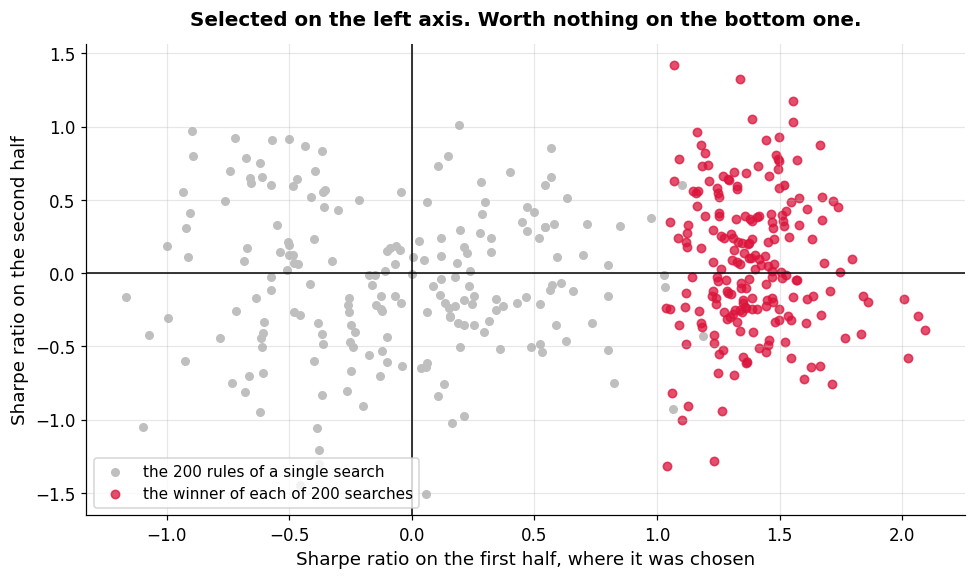

over 200 repetitions of the whole search:
   best of 200 Sharpe ratios, where it was chosen : +1.39  (worst +1.04, best +2.09)
   the same rule, on the next period                : +0.07  (spread 0.48)
   correlation between the two periods' rankings    : +0.010


In [ ]:
trading_days, trials, repeats = 2000, 200, 200
half = trading_days // 2
sharpe = lambda daily: daily.mean(axis=-1) / daily.std(axis=-1) * np.sqrt(252)


def one_search(seed):
    """Two hundred meaningless rules; pick the best on the first half, test it on the second."""
    draw = np.random.default_rng(seed)
    market = draw.normal(0, 1, trading_days)              # a market with no predictability
    rules = draw.normal(size=(trials, trading_days))      # signals with no information
    in_sample = sharpe(np.sign(rules[:, :half]) * market[:half])
    out_of_sample = sharpe(np.sign(rules[:, half:]) * market[half:])
    return in_sample, out_of_sample


# One search is one draw, so run the whole thing two hundred times and keep each winner.
best_in, chosen_out, rank_corr = [], [], []
for seed in range(repeats):
    ins, oos = one_search(seed)
    pick = ins.argmax()
    best_in.append(ins[pick]); chosen_out.append(oos[pick])
    rank_corr.append(np.corrcoef(ins, oos)[0, 1])

one_in, one_out = one_search(0)                      # one search, drawn in the background

fig, axis = plt.subplots(figsize=(9, 5.4))
axis.scatter(one_in, one_out, s=24, color="0.75", label=f"the {trials} rules of a single search")
axis.scatter(best_in, chosen_out, s=30, color="crimson", alpha=0.75,
             label=f"the winner of each of {repeats} searches")
axis.axhline(0, color="black", linewidth=1)
axis.axvline(0, color="black", linewidth=1)
axis.set_xlabel("Sharpe ratio on the first half, where it was chosen")
axis.set_ylabel("Sharpe ratio on the second half")
axis.set_title("Selected on the left axis. Worth nothing on the bottom one.")
axis.legend(loc="lower left")
plt.show()

print(f"over {repeats} repetitions of the whole search:")
print(f"   best of {trials} Sharpe ratios, where it was chosen : {np.mean(best_in):+.2f}"
      f"  (worst {np.min(best_in):+.2f}, best {np.max(best_in):+.2f})")
print(f"   the same rule, on the next period                : {np.mean(chosen_out):+.2f}"
      f"  (spread {np.std(chosen_out):.2f})")
print(f"   correlation between the two periods' rankings    : {np.mean(rank_corr):+.3f}")

One search is one draw, so the cell repeats the whole thing two hundred times. The averages are the
claim: the best of two hundred worthless rules earns a Sharpe ratio of **+1.39** on the period that
chose it — never below +1.04 in two hundred repetitions — and **+0.07** on the next period, with a
spread of 0.48 around that. For scale, the finance literature's answer to exactly this problem is to
raise the bar: after decades of published factors, Harvey, Liu and Zhu argue that a new one needs a
$t$-statistic above about 3 rather than the conventional 2, precisely because so many were tried. The in-sample ranking carries
no information at all about the out-of-sample one: the two correlate at +0.010, which is zero.

The figure shows it by shape. The grey cloud is one search: two hundred rules, spread over both
axes, with no relationship between them. Every red point is the winner of one such search, and they
line up in a band on the right — selected to be extreme on the horizontal axis — while staying
scattered around zero on the vertical one, which is the only axis that matters.

**The fix is not a better test. It is reporting the number of trials.** A threshold that is
reasonable for one hypothesis is not reasonable for the best of two hundred, and the correction
depends on how many were tried — which is why the count must be recorded while the work is done,
not reconstructed afterwards.

The literature is explicit, and it is worth knowing by name:

- **Deflated Sharpe ratio** (Bailey & López de Prado, 2014): adjust the observed ratio for the
  number of trials, their variance, and the length of the sample.
- **"...and the Cross-Section of Expected Returns"** (Harvey, Liu & Zhu, *RFS* 29, 2016): with
  hundreds of published factors, a $t$-statistic of 2 means nothing; they argue for about 3.
- **The reality check** (White, *Econometrica* 68, 2000) and data-snooping in trading rules
  (Sullivan, Timmermann & White, *JoF* 54, 1999): the formal tests for "best of many".
- Outside finance, the same argument is Ioannidis's *Why most published research findings are false*
  (*PLoS Medicine* 2, 2005), and it is what multiple-testing corrections do in a physics analysis.

> **Count the trials, including the ones you abandoned.** A model you tried and dropped is part of
> the search that produced the model you kept. This is `02C` §5's rule — the test set is spent —
> applied to the entire project rather than to one fit.

# 6. When the relationship itself changes

Everything so far assumed a fixed truth that the procedure might misjudge. The harder problem is
that the truth moves: a detector is recalibrated, a market changes regime, a policy changes, a
sensor ages. The literature calls it **concept drift** (Gama et al., *ACM Computing Surveys* 46,
2014), and it breaks something more basic than a validation scheme — it breaks the assumption that
past data describe the future at all.

The cell builds a series whose relationship **reverses** halfway through, and asks what a model
fitted on the first half is worth afterwards.

In [ ]:
length = 2000
driver = rng.normal(size=length)
slope = np.where(np.arange(length) < length // 2, 0.3, -0.3)     # the relationship flips
response = slope * driver + rng.normal(0, 1, length)

first_half = LinearRegression().fit(driver[:length // 2].reshape(-1, 1), response[:length // 2])
print(f"fitted on the first half, scored on the first half : R2 "
      f"{first_half.score(driver[:length // 2].reshape(-1, 1), response[:length // 2]):+.3f}")
print(f"the same model, scored on the second half          : R2 "
      f"{first_half.score(driver[length // 2:].reshape(-1, 1), response[length // 2:]):+.3f}")

# Refitting on a trailing window, stepping forward 50 days at a time
rolling = []
for start in range(length // 2, length, 50):
    window = slice(max(0, start - 250), start)
    model = LinearRegression().fit(driver[window].reshape(-1, 1), response[window])
    block = slice(start, start + 50)
    rolling.append(r2_score(response[block], model.predict(driver[block].reshape(-1, 1))))

print(f"\nrefitting on a rolling 250-day window, same period  : R2 {np.mean(rolling):+.3f}")
print(f"   per 50-day block: {np.round(rolling, 3)}")

fitted on the first half, scored on the first half : R2 +0.068
the same model, scored on the second half          : R2 -0.187

refitting on a rolling 250-day window, same period  : R2 +0.006
   per 50-day block: [-0.191 -0.051 -0.043 -0.023  0.049  0.044  0.03   0.004 -0.     0.071
  0.043  0.07  -0.055  0.019  0.054  0.038 -0.035 -0.036 -0.     0.139]


The model explains 6.8% of the variance on its own half and **−18.7%** on the next one: worse than
predicting the mean, because it applies a positive slope to a world that has turned negative. A
model can be well built, honestly validated, and still be wrong the day after it is deployed.

Refitting on a trailing 250-day window removes the systematic damage — a mean $R^2$ of +0.006 over
the same period, which is the right answer once the flip has passed, against −0.187 for the frozen
model. The per-block numbers show what it costs on the way: the first blocks after the flip are the
worst of the run, because the window still holds the old world, and they recover as it empties.

Three things follow, and they are why step 10 of the pipeline map has a box for monitoring:

**A model has a shelf life**, and finding it is an empirical question: compare rolling against
expanding windows, and look at when the rolling one starts winning.

**Validation should include a regime the model was not fitted on.** A walk-forward does this by
construction; a single random split never does.

**Deployment needs a monitor, not only a score.** Watching the live error against the validation
error is what tells you the world has moved, and there is a literature of detectors that do it
automatically — tracking the error rate and signalling when it degrades beyond what sampling noise
explains (Gama et al.'s survey covers the standard ones). The course names this box in step 10 and
never teaches it; this paragraph is the whole of what it would say.

# 7. What an honest report contains

For a result on ordered data, six things:

1. **The split, described in dates.** Which period trained, which validated, which tested, and the
   order they were looked at in.
2. **The label's horizon and the purge.** If labels are built over $h$ periods, say so and say
   whether the training rows within $h$ of a boundary were removed.
3. **A score per period, not only a mean.** With the periods named, so a reader can see whether one
   stretch carries the result.
4. **The number of trials**, including abandoned ones, and any correction applied for them.
5. **The refit policy.** Expanding or rolling, how long a window, how often refitted — and whether
   that policy was itself chosen by looking at the test period, which would make it another trial.
6. **What would falsify it.** The regime in which the model should stop working, stated in advance.

The closing procedure of `03C` §8 and its successors still applies; steps 1, 2 and 9 are the ones
that change, and they change into the list above.

# 8. Common pitfalls

**A random split on ordered data.** Section 2: 20% of the variance "explained" on pure noise.

**Forgetting the boundary.** Section 3: overlapping labels leak across it, and short test blocks are
almost entirely boundary.

**Reporting the mean of a walk-forward and not the periods.** It hides whether the result came from
one stretch of history.

**Tuning on the test period, in stages.** Every glance at the final period is a trial, and they
accumulate whether or not they are written down.

**Treating a long backtest as a large sample.** Overlapping labels are serially correlated by
construction, which is the oldest known problem in this corner of econometrics: overlapping
observations buy efficiency but induce autocorrelation in the residuals, and inference needs standard
errors that allow for it (Hansen & Hodrick, 1980; Newey & West, 1987). The effective number of
independent observations is smaller than the row count — dividing the span by the horizon, here
2,000 days by 20, is the usual rough guide rather than a result.

**Assuming a validated model stays valid.** Section 6: a reversal makes a good model worse than
useless, and nothing inside the model notices.

# 9. Exercises

<div class="alert alert-success">
<b>Exercise 1 — How much overlap does it take?</b><br>
Section 2 used a 20-day label on a 20-day window.
<br><br>
1. Repeat the comparison of random against forward validation for horizons of 1, 5, 20 and 60 days.<br>
2. Plot both scores against the horizon.<br>
3. At which horizon does the random split stop being misleading, and why that one?<br>
4. A colleague predicts a material's property from features averaged over a sliding window of ten
neighbouring compositions. Does the same problem apply? What plays the role of the horizon?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — The cost of the search</b><br>
Section 5 chose the best of 200 rules on half the data.
<br><br>
1. Repeat the experiment for 10, 50, 200 and 1000 trials, recording the best in-sample Sharpe ratio
each time.<br>
2. Plot it against $\sqrt{2\ln N}$, as in <code>X1</code> §2.<br>
3. Now give one rule a genuine edge — multiply its signal into the returns with a small weight —
and see how large the edge must be before the search reliably finds it among 1000 trials.<br>
4. What does part 3 say about screening a large number of weak candidate signals?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Rolling against expanding</b><br>
Section 6 used a single reversal.
<br><br>
1. Replace the abrupt flip with a slope that drifts linearly from +0.3 to −0.3 over the whole
period.<br>
2. Compare an expanding window with rolling windows of 100, 250 and 500 days, by mean $R^2$ over
the second half.<br>
3. Which window wins, and how sharply does the answer depend on the drift rate?<br>
4. You cannot see the drift rate in advance. What would you monitor in deployment to notice that
the window you chose has become too long?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- **A random split on ordered data reports performance that does not exist.** On a series with no
  signal, 5-fold cross-validation claimed $R^2 = +0.20$; forward validation gave a negative number,
  which is the truth. The cause is near-duplicate rows, not a leaked test set.
- **k-fold is not forbidden on time series** — for a purely autoregressive model on a stationary
  series with uncorrelated errors it is valid (Bergmeir, Hyndman & Koo, 2018). Overlapping labels
  and drift are what break it.
- **Purge the boundary.** With a 20-day label, unpurged predictions correlated with the truth at
  +0.28 over the twenty days after each boundary, against +0.13 purged — on data containing nothing.
  The leak is one label wide, so short test blocks are almost all boundary. The purge width follows
  from the label; the embargo width does not, and is a judgement.
- **Report a walk-forward period by period.** The folds are named stretches of history, not
  exchangeable samples.
- **The best of many trials is not an estimate.** Averaged over 200 repetitions, the best of 200
  worthless rules scored a Sharpe ratio of +1.39 where it was chosen and +0.07 afterwards, and the
  two periods' rankings correlated at +0.01.
  Report the number of trials; the corrections that exist (deflated Sharpe ratio; Harvey, Liu & Zhu,
  2016) all need that count.
- **The relationship can change.** A model fitted before a reversal scored $R^2 = -0.187$ after it,
  where refitting on a rolling window scored +0.006 — the damage is systematic, not noise. A validated model is not a permanent one,
  which is what step 10's monitoring box is for.

# Where this leaves the course

`X1` and `X2` are the two halves of one answer to a question the lectures raise and do not settle:
what to do when most of the features are useless and the data are not exchangeable.

Nothing in them contradicts the course. Every remedy here is an application of `02C`'s single rule —
**the estimate is only as honest as the split** — to a setting where the rule is harder to obey:
selection inside the folds, a split that respects the order, a gap where labels overlap, and a count
of how many times the procedure was allowed to choose.

If you take one sentence away: **the score is a property of the procedure, not of the model**, so
whatever the procedure was allowed to see, and however many times it was allowed to choose, belongs
in the report beside the number.